# 00 - Preparação

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Gerando dados sintéticos estruturados
np.random.seed(42)
n_registros = 120

datas = pd.date_range(start='2024-01-01', periods=n_registros, freq='D')
categorias = ['Eletronicos', 'Livros', 'Roupas', 'Automotivo']
estados = ['SP', 'RJ', 'MG', 'RS', 'BA']

dados = {
    'data': datas,
    'categoria': np.random.choice(categorias, size=n_registros),
    'estado': np.random.choice(estados, size=n_registros),
    'valor': np.random.uniform(50, 4500, size=n_registros).round(2),
    'quantidade': np.random.randint(1, 15, size=n_registros),
}

df = pd.DataFrame(dados)
df['valor_venda'] = (df['valor'] * np.random.uniform(0.9, 1.1, size=n_registros)).round(2)


# Parte 1 - Gráficos essenciais

**Gráfico de faturamento mensal**

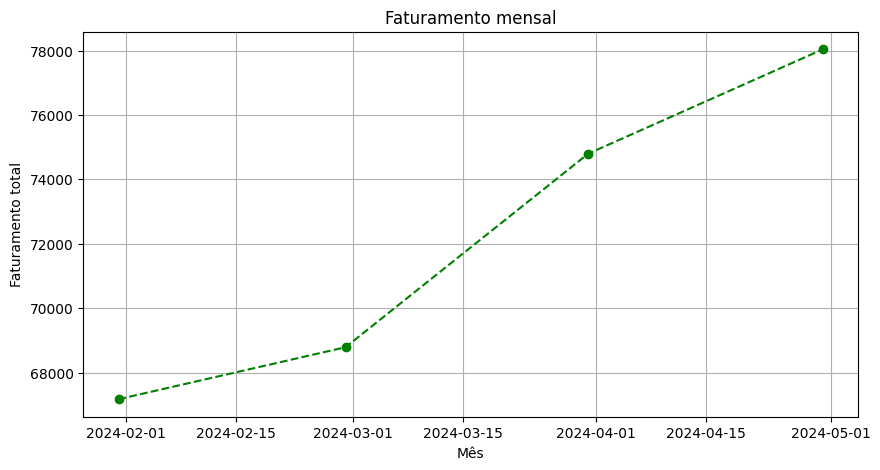

In [ ]:
faturamentoMensal = df.set_index('data')['valor_venda'].resample('ME').sum()

plt.figure(figsize=(10,5))

plt.plot(
    faturamentoMensal.index,
    faturamentoMensal.values,
    marker = "o",
    linestyle = "--",
    color = "blue"
)

plt.xlabel('Mês')
plt.ylabel('Faturamento total')
plt.title('Faturamento mensal')

plt.grid(True)

plt.show()

**Total de vendas por categoria**

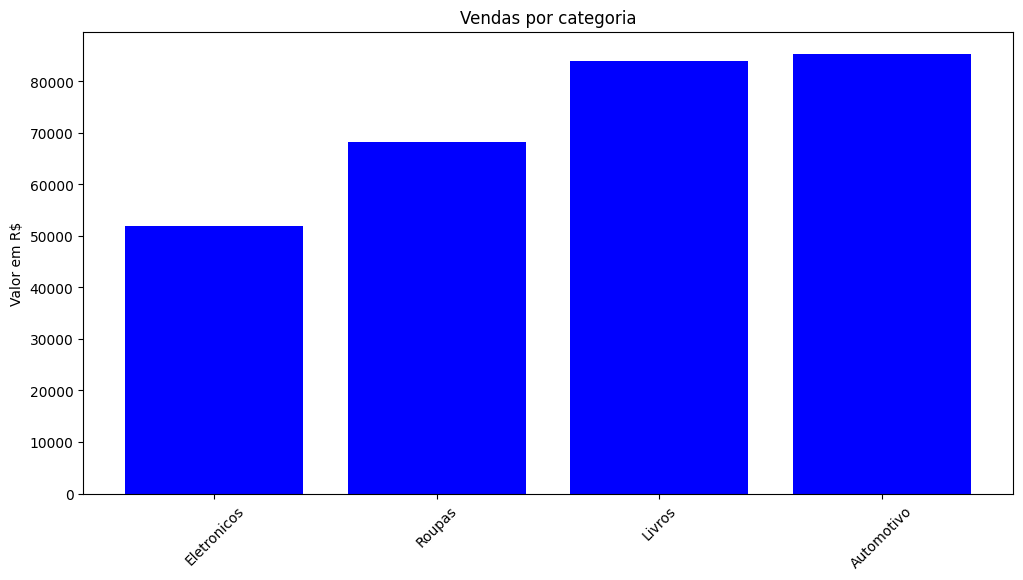

In [ ]:
vendas_categoria = df.groupby('categoria')['valor'].sum().sort_values()

plt.figure(figsize=(12,6))

plt.bar(vendas_categoria.index, vendas_categoria.values, color = "blue")

plt.title("Vendas por categoria")

plt.ylabel("Valor em R$")

plt.xticks(rotation = 45)

plt.show()


**Histograma de distribuição dos valores de vendas**

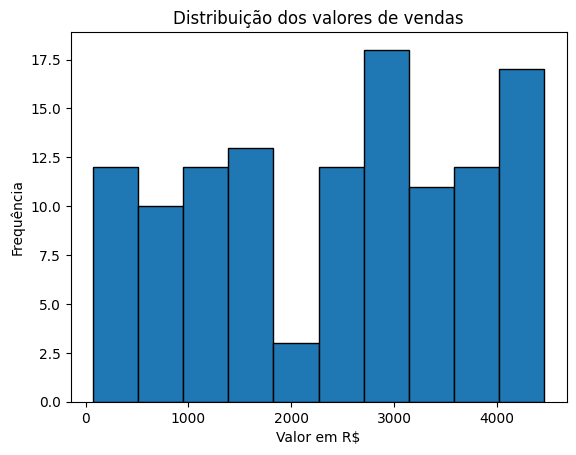

In [ ]:
plt.hist(df['valor'], bins=10, edgecolor="black")
plt.title("Distribuição dos valores de vendas")
plt.xlabel("Valor em R$")
plt.ylabel("Frequência")
plt.show()

# Parte 2 - API Orientada a Objetos e Eixos Múltiplos

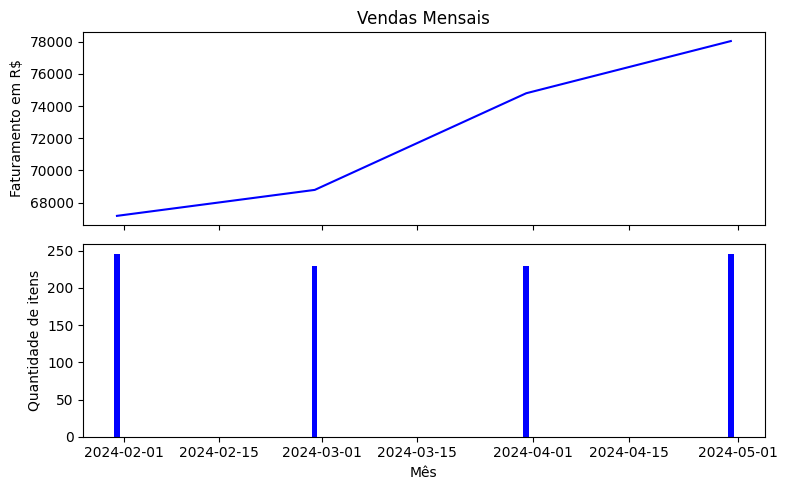

In [13]:
mensal_agg = df.set_index('data').resample('ME').agg({
    'valor_venda': 'sum',
    'quantidade': 'sum'
})

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(8, 5), sharex=True)

ax1.plot(mensal_agg.index, mensal_agg['valor_venda'], color='blue')
ax1.set_ylabel('Faturamento em R$')
ax1.set_title('Vendas Mensais')

ax2.bar(mensal_agg.index,mensal_agg['quantidade'],color='blue')

ax2.set_xlabel('Mês')
ax2.set_ylabel('Quantidade de itens')

plt.tight_layout()
plt.show()



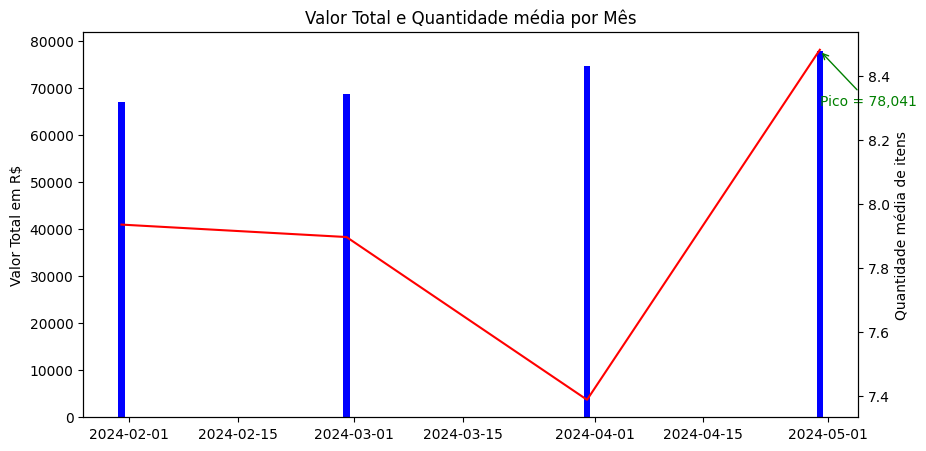

In [24]:
mensal_agg = df.set_index('data').resample('ME').agg({
    'valor_venda': 'sum',
    'quantidade': 'mean'
})
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(mensal_agg.index, mensal_agg['valor_venda'], color='blue')
ax.set_ylabel('Valor Total em R$')

ax2 = ax.twinx()
ax2.plot(mensal_agg.index, mensal_agg['quantidade'], color='red')
ax2.set_ylabel('Quantidade média de itens')

pico = faturamentoMensal.idxmax()
ax.annotate(
    f'Pico = {faturamentoMensal.max():,.0f}',
    xy=(pico, faturamentoMensal.max()),
    xytext=(pico, faturamentoMensal.max() * 0.85),
    arrowprops=dict(arrowstyle='->', color='green'),
    color='green'
)

ax.set_title('Valor Total e Quantidade média por Mês')
plt.show()

# Parte 3 - Matriz de Intensidade / Heatmap

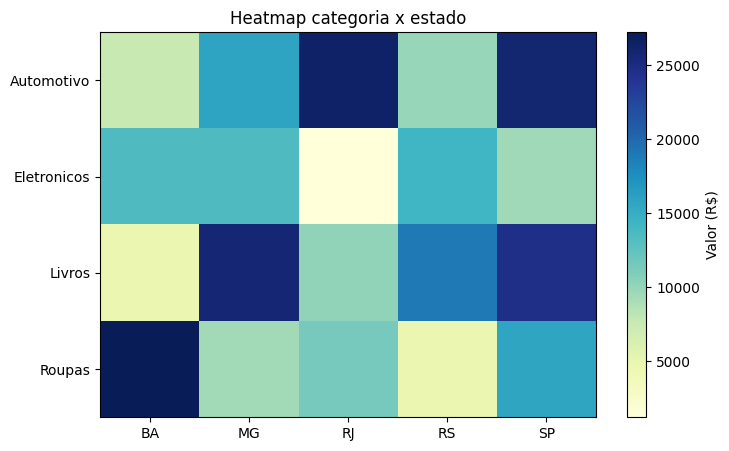

In [26]:
pivot = pd.pivot_table(df, values='valor', index='categoria', columns='estado', aggfunc='sum', fill_value=0)

plt.figure(figsize=(8, 5))
plt.imshow(pivot.values, cmap='YlGnBu', aspect='auto')
plt.colorbar(label='Valor (R$)')
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title("Heatmap categoria x estado")
plt.savefig('heatmap_vendas.png',dpi=300,bbox_inches='tight')
plt.show()